# Tahap 1 - Eksplorasi Data dan Model Prediksi

**Problem 12: Manufaktur - Optimasi Penjadwalan Pemeliharaan Mesin**

Pada tahap ini kami memeriksa dataset dan membuat model awal untuk memprediksi `sisa_umur_jam`. Hasil prediksi sisa umur mesin menjadi dasar penjadwalan perbaikan pada tahap Algoritma Genetika.

Kami memilih regresi karena target yang dicari berupa angka jam. Model linear kami wakili dengan Ridge Regression karena sederhana dan cocok sebagai pembanding awal. Decision Tree kami pilih karena kondisi mesin sering berubah pada batas tertentu, misalnya saat suhu atau getaran melewati nilai aman. Random Forest dan Gradient Boosting kami uji karena keduanya masih berbasis pohon, tetapi lebih kuat untuk membaca pola berulang pada data sensor. Logistic Regression, K-Nearest Neighbour, dan Naive Bayes tidak digunakan karena proyek ini tidak memprediksi kelas.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path(r'D:/tubes_ka')
STAGE = ROOT / 'tahap 1'
DATA_PATH = ROOT / 'ds12_manufaktur_maintenance.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,sisa_umur_jam,jam_operasi_aktif,jenis_mesin,tekanan_oli_bar,id_log_sensor,suhu_c,vibrasi_mm_s,durasi_perbaikan_jam,shift_operator,kebisingan_lingkungan_db
0,84.1,2695,Robot_Arm,2.15,LOG-00001,92.1,3.49,9,Shift_3,79.1
1,221.1,15705,Conveyor_Belt,2.22,LOG-00002,41.6,4.51,5,Shift_3,73.1
2,237.2,13436,CNC_Milling,3.60,LOG-00003,63.3,2.19,10,Shift_2,83.8
3,258.2,9338,CNC_Milling,4.34,LOG-00004,50.6,5.00,9,Shift_2,86.2
4,261.7,9227,Robot_Arm,3.85,LOG-00005,34.3,5.54,9,Shift_3,90.4


Tabel awal ini digunakan untuk memastikan dataset terbaca dengan benar. Dari lima baris pertama terlihat bahwa data berisi identitas log, jenis mesin, kondisi sensor, durasi perbaikan, shift operator, dan target `sisa_umur_jam`. Bagian ini menjadi pengecekan awal sebelum data masuk ke proses model.

## 1. Rumusan Target Prediksi

Target prediksi adalah `sisa_umur_jam`, yaitu sisa waktu mesin sebelum breakdown. Masalah ini kami kerjakan sebagai regresi karena keluaran model berupa angka jam.

In [2]:
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isna().sum())
print()
print('Statistik numerik:')
df.describe().T

Shape: (16000, 10)

Dtypes:
sisa_umur_jam               float64
jam_operasi_aktif             int64
jenis_mesin                     str
tekanan_oli_bar             float64
id_log_sensor                   str
suhu_c                      float64
vibrasi_mm_s                float64
durasi_perbaikan_jam          int64
shift_operator                  str
kebisingan_lingkungan_db    float64
dtype: object

Missing values:
sisa_umur_jam                0
jam_operasi_aktif            0
jenis_mesin                  0
tekanan_oli_bar              0
id_log_sensor                0
suhu_c                      38
vibrasi_mm_s                 0
durasi_perbaikan_jam         0
shift_operator               0
kebisingan_lingkungan_db     0
dtype: int64

Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
sisa_umur_jam,16000.0,227.592425,56.427188,1.0,210.775,237.50,265.025,311.60
jam_operasi_aktif,16000.0,10443.354375,5465.461698,1000.0,5743.000,10427.50,15166.250,19999.00
tekanan_oli_bar,16000.0,3.001375,0.805329,0.5,2.460,3.00,3.540,6.00
suhu_c,15962.0,64.795113,14.744573,30.0,54.800,64.60,74.700,120.00
vibrasi_mm_s,16000.0,4.078374,2.392803,0.1,2.320,4.01,5.700,14.82
durasi_perbaikan_jam,16000.0,6.502000,2.851842,2.0,4.000,7.00,9.000,11.00
kebisingan_lingkungan_db,16000.0,84.894456,10.058176,46.8,78.100,84.90,91.700,125.50


Output ini menunjukkan ukuran dataset, tipe kolom, missing value, dan statistik angka. Jumlah baris dan kolom memastikan data yang dibaca sesuai dengan file utama. Missing value terlihat kecil dan hanya muncul pada kolom tertentu, sehingga cukup ditangani dengan pengisian nilai. Statistik numerik membantu melihat rentang nilai sensor agar data tidak langsung digunakan tanpa pengecekan.

## 2. EDA dan Fitur Kunci

Kami menggunakan korelasi Pearson untuk melihat hubungan awal antara fitur numerik dan `sisa_umur_jam`. Hasil korelasi tetap kami cek dengan logika kasus manufaktur agar fitur yang digunakan sesuai dengan kondisi mesin.

In [3]:
target = 'sisa_umur_jam'
num_corr = df.select_dtypes(include='number').corr(numeric_only=True)[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
num_corr

jam_operasi_aktif          -0.472674
vibrasi_mm_s               -0.392713
suhu_c                     -0.222771
tekanan_oli_bar             0.154682
kebisingan_lingkungan_db   -0.004393
durasi_perbaikan_jam       -0.003333
Name: sisa_umur_jam, dtype: float64

Nilai korelasi membantu melihat fitur mana yang paling dekat hubungannya dengan `sisa_umur_jam`. Tanda negatif berarti semakin besar nilai fitur, sisa umur mesin cenderung semakin pendek. Ini masuk akal untuk fitur seperti jam operasi dan getaran, karena mesin yang lebih lama bekerja atau lebih bergetar biasanya lebih dekat ke kondisi rusak.

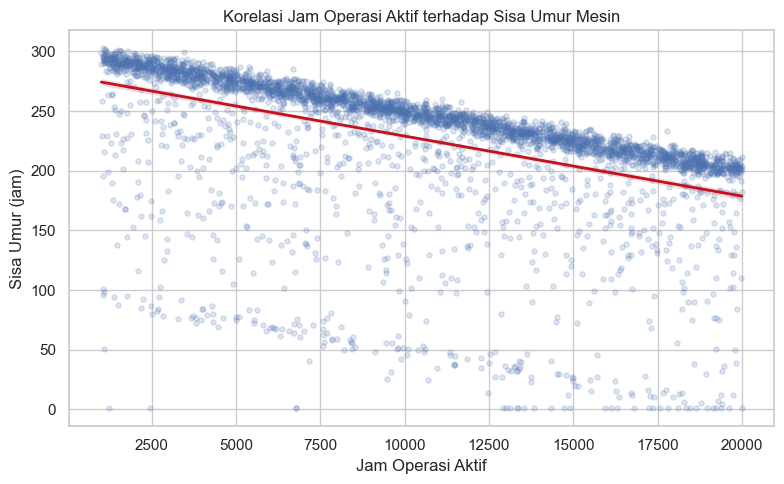

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,5))
sns.regplot(
    data=df.sample(4000, random_state=42),
    x='jam_operasi_aktif', y='sisa_umur_jam',
    scatter_kws={'alpha':0.18, 's':14},
    line_kws={'color':'#c1121f', 'linewidth':2}
)
plt.title('Korelasi Jam Operasi Aktif terhadap Sisa Umur Mesin')
plt.xlabel('Jam Operasi Aktif')
plt.ylabel('Sisa Umur (jam)')
plt.tight_layout()
plt.show()

Grafik ini memperlihatkan hubungan `jam_operasi_aktif` dengan `sisa_umur_jam`. Garis tren menurun menunjukkan bahwa mesin dengan jam operasi lebih tinggi cenderung memiliki sisa umur lebih rendah. Titik data tidak membentuk garis sempurna karena kerusakan mesin juga dipengaruhi suhu, getaran, tekanan oli, jenis mesin, dan kondisi operasional lain.

## 3. Preprocessing

Kolom `id_log_sensor` tidak digunakan sebagai fitur karena hanya berisi kode log. Kolom `durasi_perbaikan_jam` tidak digunakan untuk prediksi sisa umur, tetapi digunakan sebagai lama perbaikan pada tahap Algoritma Genetika.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

features = [
    'jam_operasi_aktif', 'jenis_mesin', 'tekanan_oli_bar', 'suhu_c',
    'vibrasi_mm_s', 'shift_operator', 'kebisingan_lingkungan_db'
]
X = df[features]
y = df[target]

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1764705882, random_state=42)

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

numeric_scaled = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
numeric_tree = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

pre_scaled = ColumnTransformer([('num', numeric_scaled, num_cols), ('cat', cat_pipe, cat_cols)])
pre_tree = ColumnTransformer([('num', numeric_tree, num_cols), ('cat', cat_pipe, cat_cols)])

print(len(X_train), len(X_val), len(X_test))

11200 2400 2400


Output pembagian data menunjukkan jumlah data training, validasi, dan testing. Training digunakan untuk melatih model, validasi untuk memilih model terbaik, dan testing untuk mengecek performa akhir pada data yang tidak dilihat saat pemilihan model.

## 4. Perbandingan Model Awal

Kami membandingkan Dummy Regressor, Ridge Regression, Decision Tree, Random Forest, dan Gradient Boosting. Penilaian model menggunakan RMSE, MAE, dan R2.

In [6]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

models = {
    'Dummy Mean': Pipeline([('preprocess', pre_tree), ('model', DummyRegressor(strategy='mean'))]),
    'Ridge Regression': Pipeline([('preprocess', pre_scaled), ('model', Ridge(alpha=1.0, random_state=42))]),
    'Decision Tree': Pipeline([('preprocess', pre_tree), ('model', DecisionTreeRegressor(max_depth=8, random_state=42))]),
    'Random Forest': Pipeline([('preprocess', pre_tree), ('model', RandomForestRegressor(n_estimators=120, max_depth=14, min_samples_leaf=2, random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('preprocess', pre_tree), ('model', GradientBoostingRegressor(n_estimators=180, learning_rate=0.06, max_depth=3, random_state=42))]),
}

def eval_model(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    return {
        'RMSE': root_mean_squared_error(y_eval, pred),
        'MAE': mean_absolute_error(y_eval, pred),
        'R2': r2_score(y_eval, pred),
    }

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    val = eval_model(model, X_val, y_val)
    test = eval_model(model, X_test, y_test)
    rows.append({'model': name, **{f'val_{k}': v for k, v in val.items()}, **{f'test_{k}': v for k, v in test.items()}})

results = pd.DataFrame(rows).sort_values('val_RMSE')
results

,model,val_RMSE,val_MAE,val_R2,test_RMSE,test_MAE,test_R2
4,Gradient Boosting,7.376717,5.239074,0.984659,7.346515,5.348086,0.983996
3,Random Forest,7.508668,4.513060,0.984105,7.572263,4.700259,0.982997
2,Decision Tree,8.200764,4.765647,0.981040,9.507077,5.186132,0.973198
1,Ridge Regression,44.276037,28.577521,0.447331,42.081381,27.026174,0.474883
0,Dummy Mean,59.642661,40.610785,-0.002863,58.084642,39.952791,-0.000457


In [7]:
import joblib
best_name = results.iloc[0]['model']
best_model = models[best_name]
model_dir = STAGE / 'models'
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, model_dir / 'best_rul_model.joblib')
print('Best model:', best_name)
print('Saved to:', model_dir / 'best_rul_model.joblib')

Best model: Gradient Boosting


Output ini memastikan model terbaik sudah tersimpan sebagai `best_rul_model.joblib`. File model ini diperlukan pada tahap berikutnya agar prediksi sisa umur mesin bisa langsung digunakan untuk penjadwalan.

## Kesimpulan Tahap 1

Model terbaik pada tahap ini adalah Gradient Boosting dengan RMSE validasi sekitar 7,38 jam dan R2 validasi sekitar 0,985. Model ini kami gunakan untuk menghasilkan prediksi sisa umur mesin pada tahap berikutnya.